In [1]:
print("Notebooken fungerar!")

Notebooken fungerar!


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("Allt fungerar!")
print("TensorFlow version:", tf.__version__)

Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.
Instructions for updating:
The TensorFlow Distributions library has moved to TensorFlow Probability (https://github.com/tensorflow/probability). You should update all references to use `tfp.distributions` instead of `tf.distributions`.
Allt fungerar!
TensorFlow version: 2.13.0


# Klassificering av ansiktsuttryck med Deep Learning (CNN)

## Individuell inlämningsuppgift – Deep Learning

**Namn:** Eliesa Dudus  
**Modelltyp:** Convolutional Neural Network (CNN)  
**Dataset:** FER-2013 (Facial Expression Recognition)

### Syfte
Målet med uppgiften är att bygga en deep learning-modell som kan klassificera ansiktsuttryck från bilder. Modellen ska tränas, utvärderas och användas för att göra prediktioner på ny data.

In [3]:
import os

# Vägar till datasetet
train_path = "train"
test_path = "test"

# Visa vilka klasser som finns
classes = os.listdir(train_path)

print("Klasser i datasetet:")
print(classes)

print("\nAntal klasser:", len(classes))

Klasser i datasetet:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Antal klasser: 7


In [4]:
# Räkna antal bilder per klass

print("Antal bilder per klass i träningsdata:\n")

for emotion in classes:
    path = os.path.join(train_path, emotion)
    num_images = len(os.listdir(path))
    print(f"{emotion}: {num_images} bilder")

Antal bilder per klass i träningsdata:

angry: 3995 bilder
disgust: 436 bilder
fear: 4097 bilder
happy: 7215 bilder
neutral: 4965 bilder
sad: 4830 bilder
surprise: 3171 bilder


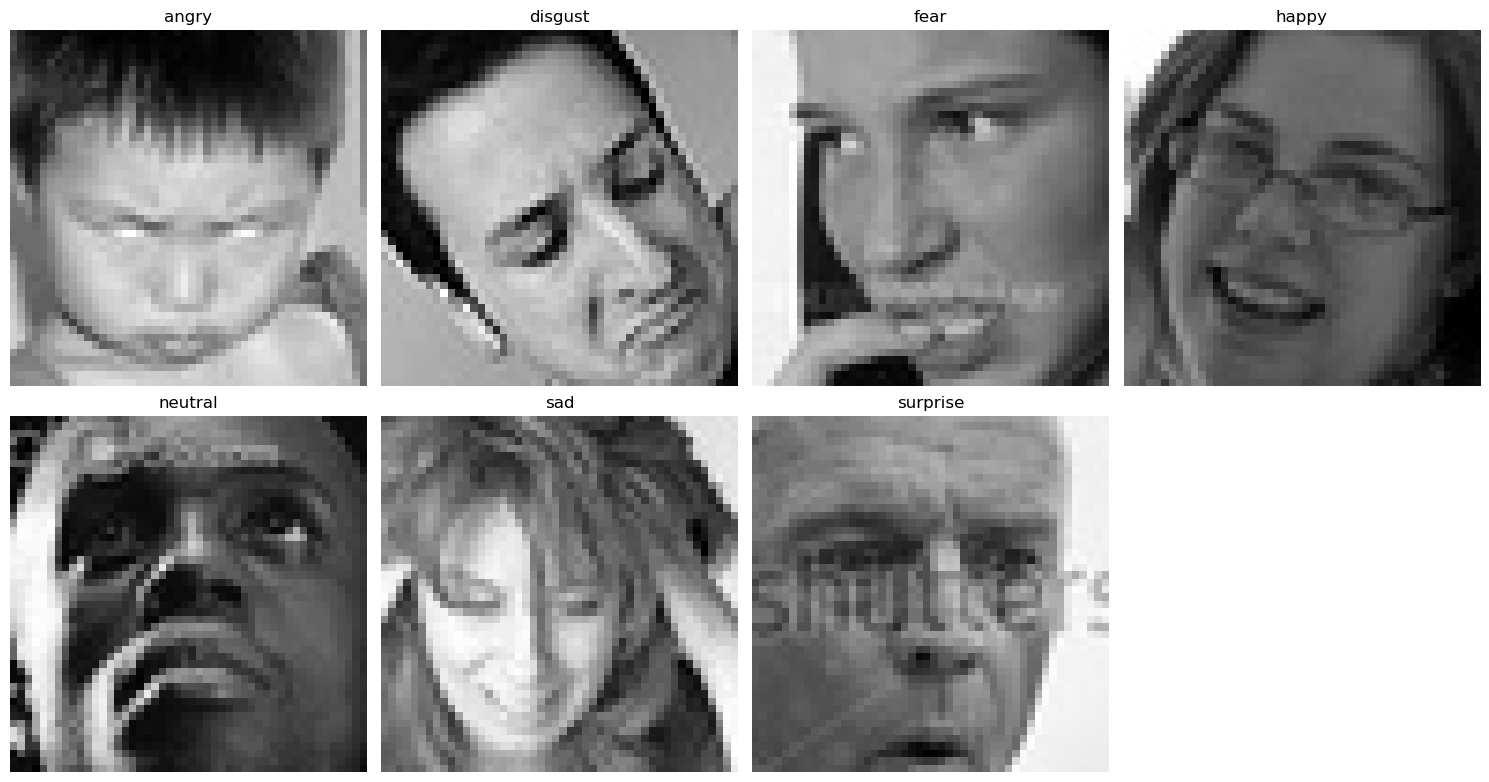

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Visa en bild från varje klass
plt.figure(figsize=(15, 8))

for i, emotion in enumerate(classes):
    image_path = os.path.join(train_path, emotion)
    image_name = os.listdir(image_path)[0]
    img = mpimg.imread(os.path.join(image_path, image_name))

    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(emotion)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 1. Förstå datan

Datasetet innehåller gråskalebilder på ansikten med storleken 48x48 pixlar. Bilderna är uppdelade i sju olika klasser av ansiktsuttryck:

- angry
- disgust
- fear
- happy
- neutral
- sad
- surprise

Vid undersökning av träningsdatan kunde det ses att datasetet är obalanserat. Klassen *happy* innehåller flest bilder medan *disgust* innehåller betydligt färre exempel. Detta kan påverka modellens prestation eftersom modellen sannolikt blir bättre på klasser med mer träningsdata.

Exempelbilder från varje klass visualiserades för att förstå hur bilderna ser ut och hur ansiktsuttrycken skiljer sig åt. Vissa känslor, exempelvis *fear*, *sad* och *neutral*, verkar visuellt mer lika varandra vilket kan göra klassificeringen mer utmanande.

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Normalisera bilderna (skala pixelvärden mellan 0 och 1)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Ladda träningsdata
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(48, 48),
    batch_size=32,
    color_mode='grayscale',
    class_mode='categorical',
    subset='training'
)

# Validation data
validation_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(48, 48),
    batch_size=32,
    color_mode='grayscale',
    class_mode='categorical',
    subset='validation'
)

# Testdata
test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(48, 48),
    batch_size=32,
    color_mode='grayscale',
    class_mode='categorical'
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


## 2. Förbered datan

Bilderna lästes in från mapparna `train` och `test`. Eftersom bilderna är gråskalebilder användes `color_mode='grayscale'`, och alla bilder skalades till storleken 48x48 pixlar.

Pixelvärdena normaliserades genom att divideras med 255, vilket gör att värdena hamnar mellan 0 och 1. Detta är viktigt eftersom neurala nätverk tränas mer stabilt när inputdata är normaliserad.

Träningsdatan delades även upp i träningsdata och validation-data. Validation används under träningen för att se hur modellen presterar på data den inte tränas direkt på.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model_1 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(7, activation='softmax')
])

model_1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 46, 46, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 23, 23, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 21, 21, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 10, 10, 64)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 6400)              0         
                                                                 
 dense (Dense)               (None, 128)               8

In [8]:
history_1 = model_1.fit(
    train_data,
    epochs=5,
    validation_data=validation_data
)

Epoch 1/5
718/718 [==============================] - 311s 430ms/step - loss: 1.6020 - accuracy: 0.3764 - val_loss: 1.4666 - val_accuracy: 0.4356
Epoch 2/5
718/718 [==============================] - 50s 69ms/step - loss: 1.3728 - accuracy: 0.4764 - val_loss: 1.3801 - val_accuracy: 0.4734
Epoch 3/5
718/718 [==============================] - 49s 68ms/step - loss: 1.2532 - accuracy: 0.5237 - val_loss: 1.3030 - val_accuracy: 0.5018
Epoch 4/5
718/718 [==============================] - 43s 60ms/step - loss: 1.1492 - accuracy: 0.5690 - val_loss: 1.2783 - val_accuracy: 0.5133
Epoch 5/5
718/718 [==============================] - 47s 65ms/step - loss: 1.0459 - accuracy: 0.6055 - val_loss: 1.2885 - val_accuracy: 0.5156


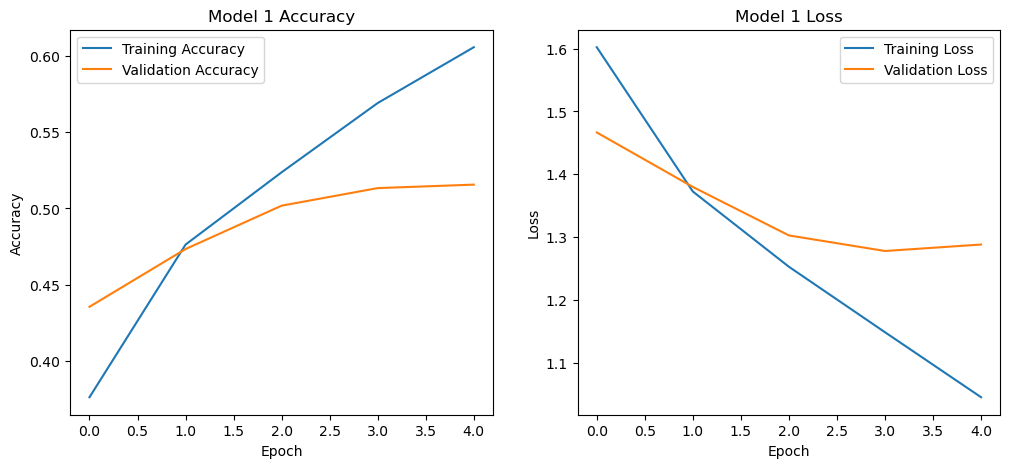

In [9]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_1.history['accuracy'], label='Training Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 1 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_1.history['loss'], label='Training Loss')
plt.plot(history_1.history['val_loss'], label='Validation Loss')
plt.title('Model 1 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [10]:
test_loss_1, test_accuracy_1 = model_1.evaluate(test_data)

print("Test accuracy:", test_accuracy_1)
print("Test loss:", test_loss_1)

225/225 [==============================] - 73s 324ms/step - loss: 1.2730 - accuracy: 0.5166
Test accuracy: 0.5165784358978271
Test loss: 1.2730249166488647


## 3. Modell 1 – Basmodell

Den första modellen byggdes som en enkel CNN med två convolutional layers, två max pooling-lager och ett dense-lager innan output-lagret.

Modellen uppnådde ungefär 52% accuracy på testdata. Eftersom validation accuracy och test accuracy ligger nära varandra verkar modellen generalisera ungefär lika bra på validation- och testdata.

Träningskurvorna visar däremot att training accuracy fortsätter öka medan validation accuracy planar ut efter några epochs. Samtidigt minskar training loss tydligt, medan validation loss inte förbättras lika mycket i slutet. Detta tyder på en viss overfitting, eftersom modellen lär sig träningsdatan bättre än ny data.

In [11]:
from tensorflow.keras.layers import Dropout

model_2 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

model_2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 46, 46, 32)        320       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 23, 23, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 21, 21, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 10, 10, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 8, 8, 128)         73856     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 4, 4, 128)        

In [12]:
history_2 = model_2.fit(
    train_data,
    epochs=8,
    validation_data=validation_data
)

Epoch 1/8
718/718 [==============================] - 59s 81ms/step - loss: 1.7512 - accuracy: 0.2841 - val_loss: 1.6031 - val_accuracy: 0.3923
Epoch 2/8
718/718 [==============================] - 46s 64ms/step - loss: 1.5295 - accuracy: 0.4059 - val_loss: 1.4305 - val_accuracy: 0.4501
Epoch 3/8
718/718 [==============================] - 49s 68ms/step - loss: 1.4056 - accuracy: 0.4617 - val_loss: 1.3490 - val_accuracy: 0.4914
Epoch 4/8
718/718 [==============================] - 50s 69ms/step - loss: 1.3274 - accuracy: 0.4943 - val_loss: 1.2966 - val_accuracy: 0.5036
Epoch 5/8
718/718 [==============================] - 49s 69ms/step - loss: 1.2732 - accuracy: 0.5168 - val_loss: 1.2876 - val_accuracy: 0.5060
Epoch 6/8
718/718 [==============================] - 50s 69ms/step - loss: 1.2201 - accuracy: 0.5374 - val_loss: 1.2541 - val_accuracy: 0.5229
Epoch 7/8
718/718 [==============================] - 50s 70ms/step - loss: 1.1878 - accuracy: 0.5500 - val_loss: 1.2329 - val_accuracy: 0.5309

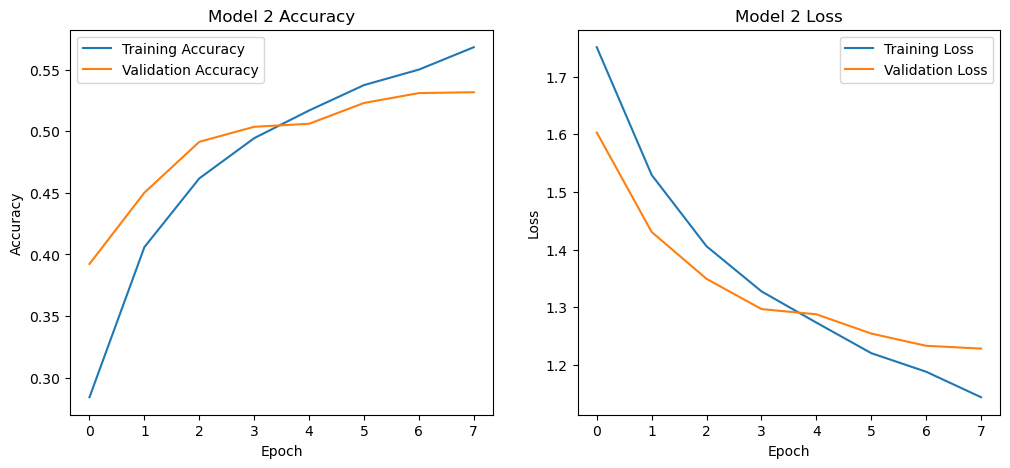

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_2.history['accuracy'], label='Training Accuracy')
plt.plot(history_2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_2.history['loss'], label='Training Loss')
plt.plot(history_2.history['val_loss'], label='Validation Loss')
plt.title('Model 2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [14]:
test_loss_2, test_accuracy_2 = model_2.evaluate(test_data)

print("Test accuracy:", test_accuracy_2)
print("Test loss:", test_loss_2)

225/225 [==============================] - 12s 54ms/step - loss: 1.2145 - accuracy: 0.5375
Test accuracy: 0.5374756455421448
Test loss: 1.214528203010559


## 4. Modellförbättring och jämförelse

För att förbättra modellens prestation skapades en andra modell. I modell 2 lades ett extra convolutional layer till och ett dropout-lager användes för att minska risken för overfitting.

Modell 1 uppnådde cirka 52% accuracy på testdata medan modell 2 uppnådde ungefär 54%. Detta visar att förändringarna förbättrade modellens förmåga att klassificera ansiktsuttryck.

Träningskurvorna visar också att modell 2 generaliserade bättre än modell 1. Validation accuracy fortsatte förbättras under fler epochs och validation loss minskade mer stabilt. Detta tyder på att dropout hjälpte modellen att undvika viss overfitting.

Sammantaget presterade modell 2 bättre och valdes därför som den bästa modellen.

In [15]:
model_2.save("best_fer2013_model.keras")

print("Modellen är sparad!")

Modellen är sparad!


1/1 [==============================] - 0s 19ms/step


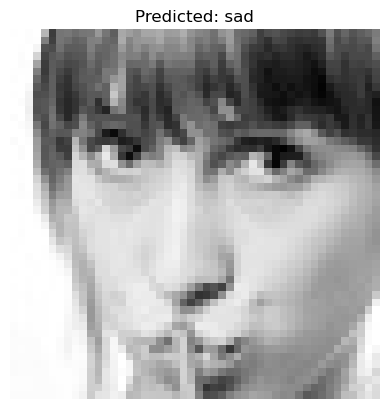

Faktisk klass: neutral
Prediktion: sad


In [17]:
from tensorflow.keras.preprocessing import image
import numpy as np
import random

# Klassnamn
class_names = list(train_data.class_indices.keys())

# Slumpmässig testbild
random_class = random.choice(class_names)
image_folder = os.path.join(test_path, random_class)
image_name = random.choice(os.listdir(image_folder))
image_path = os.path.join(image_folder, image_name)

# Ladda bild
img = image.load_img(
    image_path,
    target_size=(48,48),
    color_mode='grayscale'
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Prediktion
prediction = model_2.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

# Visa bild
plt.imshow(img, cmap='gray')
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()

print("Faktisk klass:", random_class)
print("Prediktion:", predicted_class)

## 5. Prediktion på ny data

Den bästa modellen användes för att göra en prediktion på en ny bild från testdatan. Bilden hade inte använts under träningen.

I detta exempel predikterade modellen känslan *sad*, medan den faktiska klassen var *neutral*. Detta visar att modellen inte alltid klassificerar korrekt, särskilt när ansiktsuttryck är visuellt lika varandra.

Detta är förståeligt eftersom bilderna har låg upplösning (48x48 pixlar), och vissa känslor såsom *sad*, *neutral* och *fear* kan vara svåra att skilja åt även för människor.

## 6. Analys av resultat

### Hur bra fungerar modellen?

Modellen fungerade relativt bra med tanke på att datasetet är komplext och att bilderna endast består av gråskalebilder med låg upplösning (48x48 pixlar). Den bästa modellen uppnådde cirka 54% accuracy på testdata.

Även om resultatet inte är perfekt visar modellen att den har lärt sig identifiera mönster i ansiktsuttryck och kan klassificera känslor bättre än slumpmässiga gissningar.

### Finns det tecken på overfitting eller underfitting?

I modell 1 kunde vissa tecken på overfitting observeras. Training accuracy fortsatte att öka medan validation accuracy började plana ut efter några epochs. Samtidigt förbättrades validation loss mindre tydligt mot slutet.

I modell 2 minskade problemet något genom att lägga till dropout och ett extra convolutional layer. Validation accuracy fortsatte förbättras under fler epochs och modellen generaliserade bättre till ny data.

### Hur skiljer sig resultaten mellan träningsdata och testdata?

Modellen presterade bättre på träningsdata än på testdata, vilket är vanligt inom deep learning. Modell 2 uppnådde ungefär 57% accuracy på träningsdata och cirka 54% på testdata.

Skillnaden mellan träning och test var dock inte extremt stor, vilket tyder på att modellen fortfarande generaliserar relativt bra.

### Vad verkar påverka resultatet mest?

Flera faktorer verkar påverka resultatet:

- Datasetet är obalanserat, där vissa klasser har betydligt fler bilder än andra.
- Bildernas låga upplösning gör det svårt att urskilja detaljer.
- Vissa känslor liknar varandra visuellt, exempelvis *neutral*, *sad* och *fear*.
- Modellarkitekturen påverkar tydligt resultatet, eftersom modell 2 presterade bättre efter att fler lager och dropout lades till.

### Vilka begränsningar har modellen?

Modellen har flera begränsningar. Den gör ibland felaktiga klassificeringar mellan liknande känslor och påverkas sannolikt av att vissa klasser innehåller för få exempel, exempelvis *disgust*.

Dessutom tränades modellen endast under ett begränsat antal epochs för att hålla träningstiden rimlig. Resultatet hade sannolikt kunnat förbättras ytterligare med mer träning, fler justeringar och eventuellt data augmentation.

## 7. Reflektion

### Vad var svårast i uppgiften?

Det svåraste var att få modellen att fungera på ett bra sätt och förstå hur olika förändringar påverkade resultatet. Det tog även tid att förstå hur data skulle förberedas korrekt innan modellen kunde tränas.

### Vad lärde du dig?

Jag lärde mig hur convolutional neural networks (CNN) fungerar och hur de kan användas för bildklassificering. Jag lärde mig också hur träningsdata, validation-data och testdata används, samt hur man kan identifiera tecken på overfitting genom träningskurvor.

Dessutom lärde jag mig att små förändringar i modellens struktur, exempelvis fler lager och dropout, kan förbättra resultatet.

### Vad hade du gjort annorlunda om du började om?

Om jag började om hade jag testat fler modellvarianter och experimenterat mer med hyperparametrar, exempelvis antal epochs, batch size och fler lager. Jag hade även velat testa data augmentation för att förbättra generalisering och minska overfitting.

### Vilket betyg tycker du att din inlämning motsvarar?

Jag tycker att inlämningen motsvarar **VG**, eftersom flera modellvarianter testades och jämfördes, modellen förbättrades genom förändringar i arkitekturen, och resultaten analyserades med hjälp av träningskurvor, testresultat och diskussion kring overfitting och begränsningar.